<a href="https://colab.research.google.com/github/lucalomazziPolimi/Pia-Enhance-Course/blob/main/04_workshops/01_workshop_fsi/FSI_DL_session.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Engineering Problems
## Hands-on Session 1: Predicting Fluid-Structure Interaction Effects on Blast-Loaded Plates

---

### Context

When a blast wave hits a flexible plate, the plate deforms. This deformation changes the pressure field acting on it — and that pressure change, in turn, affects the deformation. This two-way coupling is called **Fluid-Structure Interaction (FSI)**.

In engineering practice, FSI is expensive to simulate: it requires a **coupled** analysis where the fluid and the structure are solved simultaneously. Most design tools instead use **uncoupled** simulations, where the blast pressure is computed on a rigid structure and then applied to a deformable one. This is faster but ignores FSI — and as a result, it **overestimates** the plate displacement.

The question we want to answer with deep learning is:

> *Given the output of a cheap uncoupled simulation, can a neural network predict the correction to apply to account for FSI effects?*

---

### Problem setup

The dataset was generated from numerical simulations of fully clamped metal plates (steel and aluminium) subjected to blast loading in a shock tube facility. For each scenario, both an uncoupled and a coupled simulation were run.

After post-processing, each plate element in each scenario yields:

| Variable | Symbol | Source |
|---|---|---|
| Peak overpressure | $p^p_U$ | Uncoupled simulation |
| Max out-of-plane velocity | $v^p_U$ | Uncoupled simulation |
| Out-of-plane displacement | $d^p_U$ | Uncoupled simulation |
| Mass per unit area | $m_a = \rho \cdot h$ | Plate property |
| **FSI correction factor** | $d^p_C - d^p_U$ | **Target** (coupled − uncoupled) |

The correction factor is **negative**: FSI reduces displacement compared to the uncoupled prediction.

---

### What we will do in this session

1. **Load and explore** the dataset
2. **Extract scalar features** from the raw time-series simulation data
3. **Train DNN1**: a minimal network trained on a single material/thickness, *without* $m_a$ as input
4. **Train DNN5**: a richer network trained across materials and thicknesses, *with* $m_a$ as input
5. **Compare** their generalisation performance and understand *why* one works better than the other

---
## Block 1 — Setup and Imports

In [ ]:
# Mount Google Drive and install dependencies

from google.colab import drive
drive.mount('/content/drive')

!pip install torch torchvision --quiet

Mounted at /content/drive


In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# ── Device setup ─────────────────────────────────────────────────────────────
# Automatically use GPU if available (Colab: Runtime > Change runtime type > T4 GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('  No GPU found — training will be slower. In Colab: Runtime > Change runtime type > T4 GPU')

print(f'PyTorch version: {torch.__version__}')
print(f'NumPy version:   {np.__version__}')

Using device: cuda
  GPU: Tesla T4
  Memory: 15.6 GB
PyTorch version: 2.10.0+cu128
NumPy version:   2.0.2


---
## Block 2 — Data Loading and Exploration

The dataset is stored as a nested Python dictionary with the following structure:

```
dataset[material][thickness][load_case][simulation]
```

Each leaf is a **matrix** with:
- **Rows** → time instants
- **Columns**:
  - `0` → analysis time [ms]
  - `1:626` → element velocity [m/s] (one column per element)
  - `626:1251` → element displacement [m]
  - `1251:1876` → element overpressure [Pa]

There are **625 elements** in the plate mesh (one quarter model → 125 elements in the exposed area, as used in the paper).

There are two simulation types:
- `'Lagrangian'` → uncoupled simulation
- `'FSI'` → coupled simulation (includes fluid-structure interaction)

In [ ]:
# ── Load the dataset ──────────────────────────────────────────────────────────

DATASET_PATH = 'drive/MyDrive/Colab datasets/dataset.pickle'

with open(DATASET_PATH, 'rb') as f:
    dataset = pickle.load(f)

print('Dataset loaded successfully.')

Dataset loaded successfully.


In [ ]:
# ── Explore the top-level structure ──────────────────────────────────────────

materials   = list(dataset.keys())
print('Materials:', materials)

print()
for mat in materials:
    thicknesses = list(dataset[mat].keys())
    for th in thicknesses:
        load_cases = list(dataset[mat][th].keys())
        sims       = list(dataset[mat][th][load_cases[0]].keys())
        print(f'  {mat:15s} | {th:6s} | load cases: {load_cases} | sims: {sims}')

Materials: ['Docol600DL', 'Docol1000DP', 'Docol1400M', '1050-H14', '6082-T6']

  Docol600DL      | 0.8mm  | load cases: ['D7705', 'D7715', 'D7725', 'D7735', 'D7760'] | sims: ['Lagrangian', 'FSI']
  Docol600DL      | 2.0mm  | load cases: ['D7705', 'D7715', 'D7725', 'D7735', 'D7760'] | sims: ['Lagrangian', 'FSI']
  Docol1000DP     | 0.8mm  | load cases: ['D7705', 'D7715', 'D7725', 'D7735', 'D7760'] | sims: ['Lagrangian', 'FSI']
  Docol1400M      | 0.8mm  | load cases: ['D7705', 'D7715', 'D7725', 'D7735', 'D7760'] | sims: ['Lagrangian', 'FSI']
  1050-H14        | 0.8mm  | load cases: ['A5', 'A7', 'A10'] | sims: ['Lagrangian', 'FSI']
  6082-T6         | 2.0mm  | load cases: ['D7705', 'D7715', 'D7735', 'D7760'] | sims: ['Lagrangian', 'FSI']
  6082-T6         | 0.8mm  | load cases: ['D7705', 'D7715', 'D7735', 'D7760'] | sims: ['Lagrangian', 'FSI']
  6082-T6         | 3.3mm  | load cases: ['D7705', 'D7715', 'D7735', 'D7760'] | sims: ['Lagrangian', 'FSI']
  6082-T6         | 5.8mm  | load case

In [ ]:
# ── Inspect one matrix ───────────────────────────────────────────────────────
# Let's look at Docol600DL, 0.8mm plate, first available load case, Lagrangian sim

mat  = 'Docol600DL'
th   = '0.8mm'
lc   = list(dataset[mat][th].keys())[0]   # first load case
sim  = 'Lagrangian'

M = dataset[mat][th][lc][sim]
print(f'Scenario: {mat} | {th} | {lc} | {sim}')
print(f'Matrix shape: {M.shape}  (rows=time steps, cols=channels)')
print()
print('Column layout:')
print('  col  0       : time [ms]')
print('  cols 1:626   : velocity [m/s]  — 625 elements')
print('  cols 626:1251: displacement [m]— 625 elements')
print('  cols 1251:1876: overpressure [Pa]— 625 elements')

Scenario: Docol600DL | 0.8mm | D7705 | Lagrangian
Matrix shape: (51, 2501)  (rows=time steps, cols=channels)

Column layout:
  col  0       : time [ms]
  cols 1:626   : velocity [m/s]  — 625 elements
  cols 626:1251: displacement [m]— 625 elements
  cols 1251:1876: overpressure [Pa]— 625 elements


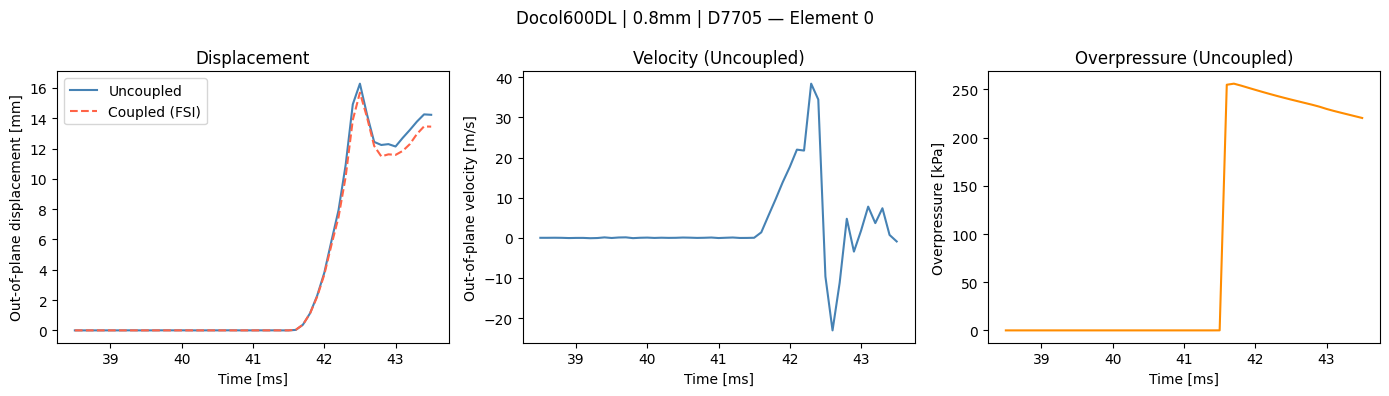


Observation: the uncoupled simulation OVERESTIMATES displacement compared to FSI.
The difference at peak displacement is what our network will learn to predict.


In [ ]:
# ── Visualise time histories for a representative element ────────────────────
# We'll look at the centre element (element index 0 by convention; check Elements.pdf
# to verify which element corresponds to the plate centre in your numbering)

ELEM_IDX = 0   # <- element index (0-based within the 625-element mesh)

M_lag = dataset[mat][th][lc]['Lagrangian']
M_fsi = dataset[mat][th][lc]['FSI']

time       = M_lag[:, 0]                         # [ms]
vel_lag    = M_lag[:, 1 + ELEM_IDX]              # [m/s]
disp_lag   = M_lag[:, 626 + ELEM_IDX] * 1e3      # convert m -> mm
pres_lag   = M_lag[:, 1251 + ELEM_IDX] * 1e-3    # convert Pa -> kPa

disp_fsi   = M_fsi[:, 626 + ELEM_IDX] * 1e3      # [mm]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'{mat} | {th} | {lc} — Element {ELEM_IDX}', fontsize=12)

axes[0].plot(time, disp_lag, label='Uncoupled', color='steelblue')
axes[0].plot(time, disp_fsi, label='Coupled (FSI)', color='tomato', linestyle='--')
axes[0].set_xlabel('Time [ms]')
axes[0].set_ylabel('Out-of-plane displacement [mm]')
axes[0].legend()
axes[0].set_title('Displacement')

axes[1].plot(time, vel_lag, color='steelblue')
axes[1].set_xlabel('Time [ms]')
axes[1].set_ylabel('Out-of-plane velocity [m/s]')
axes[1].set_title('Velocity (Uncoupled)')

axes[2].plot(time, pres_lag, color='darkorange')
axes[2].set_xlabel('Time [ms]')
axes[2].set_ylabel('Overpressure [kPa]')
axes[2].set_title('Overpressure (Uncoupled)')

plt.tight_layout()
plt.show()

print()
print('Observation: the uncoupled simulation OVERESTIMATES displacement compared to FSI.')
print('The difference at peak displacement is what our network will learn to predict.')

In [ ]:
# ── Quantify the FSI correction for this scenario ───────────────────────────
# The correction factor at peak displacement (plate centre) is what the DNN targets.

# Find the time index of maximum displacement at the centre element (Lagrangian)
centre_disp_lag = M_lag[:, 626 + ELEM_IDX] * 1e3   # mm
centre_disp_fsi = M_fsi[:, 626 + ELEM_IDX] * 1e3   # mm

t_peak_idx = np.argmax(centre_disp_lag)
d_lag_peak = centre_disp_lag[t_peak_idx]
d_fsi_peak = centre_disp_fsi[t_peak_idx]
correction  = d_fsi_peak - d_lag_peak

print(f'Peak displacement (uncoupled): {d_lag_peak:.2f} mm')
print(f'Displacement at same instant (coupled): {d_fsi_peak:.2f} mm')
print(f'FSI correction factor: {correction:.2f} mm  ({100*correction/d_lag_peak:.1f}%)')
print()
print('This negative correction is what the neural network will learn to predict')
print('from the uncoupled simulation outputs alone.')

Peak displacement (uncoupled): 16.28 mm
Displacement at same instant (coupled): 15.69 mm
FSI correction factor: -0.60 mm  (-3.7%)

This negative correction is what the neural network will learn to predict
from the uncoupled simulation outputs alone.


### ✅ End of Block 2

You should now have a clear picture of:
- How the dataset is structured
- What the raw time-series data looks like for one element in one scenario
- What the FSI correction factor is physically, and why it is always negative

In the next block, we will extract the **scalar features** from all time histories to build the training and test tables.

---
## Block 3 — Feature Extraction

Each time-series matrix contains hundreds of time steps per element. The neural network does not work on time series — it works on **scalar summaries** of those series. This is the post-processing step described in the paper.

For each element $i$ in each scenario, we extract:

| Feature | How to extract it |
|---|---|
| $d^p_U$ | Displacement at the time instant $t_d$ when the **plate centre** reaches its maximum displacement (uncoupled) |
| $v^p_U$ | **Maximum** velocity over the full time history (uncoupled) |
| $p^p_U$ | **Peak** overpressure over the full time history (uncoupled) |
| $m_a$ | $\rho \cdot h$ — a constant for each scenario, not extracted from the time series |
| $d^p_C - d^p_U$ | Displacement from **coupled** simulation at $t_d$, minus $d^p_U$ — this is the **target** |

**Key subtlety:** $t_d$ is determined by the **centre element** of the plate (maximum displacement over time), and then applied to **all elements** of the same scenario. This ensures all elements share a common reference time.

The cell below implements this extraction and is **pre-written** — read through it carefully before running it, as it encodes all of the above logic.

In [ ]:
# ── Material properties (density and thickness -> mass per unit area) ─────────
# These are taken from Tables 2 and 3 of the paper.
# m_a = rho * h  [kg/m^2]

DENSITY = {
    'Docol600DL':  7850.0,   # kg/m^3  (steel)
    'Docol1000DP': 7850.0,
    'Docol1400M':  7850.0,
    '6082-T6':     2700.0,   # kg/m^3  (aluminium)
    '1050-H14':    2700.0,
}

THICKNESS = {
    '0.8mm': 0.0008,
    '2.0mm': 0.0020,
    '3.3mm': 0.0033,
    '5.8mm': 0.0058,
}

# Number of elements in the exposed area (one quarter model)
N_ELEMENTS = 125

# Column offsets in the data matrix (0-based, element index within 0..624)
COL_TIME   = 0
COL_VEL    = 1          # velocity starts at col 1,    ends at col 625 (inclusive)
COL_DISP   = 626        # displacement starts at col 626
COL_PRES   = 1251       # overpressure starts at col 1251

# Centre element index — the element at the plate centre in the quarter model.
# According to the paper, t_d is determined by the centre element maximum displacement.
# Verify this against Elements.pdf: adjust if needed.
CENTRE_ELEM = 0

print('Material/thickness lookup tables ready.')

Material/thickness lookup tables ready.


In [ ]:
# ── Feature extraction function ───────────────────────────────────────────────
# This function processes ONE scenario (one material / thickness / load case)
# and returns an array of shape (N_ELEMENTS, 5):
#   columns: [d_U, v_U, p_U, m_a, correction]

def extract_features(M_lag, M_fsi, rho, h):
    """
    Parameters
    ----------
    M_lag : np.ndarray, shape (T, 1876+)
        Matrix from the Lagrangian (uncoupled) simulation.
    M_fsi : np.ndarray, shape (T, 1876+)
        Matrix from the FSI (coupled) simulation.
    rho : float
        Material density [kg/m^3].
    h : float
        Plate thickness [m].

    Returns
    -------
    features : np.ndarray, shape (N_ELEMENTS, 5)
        Columns: d_U [mm], v_U [m/s], p_U [kPa], m_a [kg/m^2], correction [mm]
    """

    # --- Step 1: find t_d — time index of max displacement at the plate centre ---
    centre_disp_lag = M_lag[:, COL_DISP + CENTRE_ELEM]   # [m]
    t_d = np.argmax(centre_disp_lag)                      # index, not time value

    # --- Step 2: mass per unit area (constant for all elements in this scenario) ---
    m_a = rho * h   # [kg/m^2]

    # --- Step 3: loop over the N_ELEMENTS elements in the exposed area ---
    features = np.zeros((N_ELEMENTS, 5))

    for i in range(N_ELEMENTS):

        # Displacement at t_d from uncoupled simulation [m -> mm]
        d_U = M_lag[t_d, COL_DISP + i] * 1e3

        # Maximum velocity over time from uncoupled simulation [m/s]
        v_U = np.max(M_lag[:, COL_VEL + i])

        # Peak overpressure from uncoupled simulation [Pa -> kPa]
        p_U = np.max(M_lag[:, COL_PRES + i]) * 1e-3

        # Displacement at t_d from coupled simulation [m -> mm]
        d_C = M_fsi[t_d, COL_DISP + i] * 1e3

        # FSI correction factor [mm]  — always <= 0
        correction = d_C - d_U

        features[i] = [d_U, v_U, p_U, m_a, correction]

    return features

print('extract_features() defined.')

extract_features() defined.


In [ ]:
# ── Run extraction over the full dataset ─────────────────────────────────────
# We store results in a dictionary mirroring the dataset structure,
# and also accumulate a flat list for easy assembly into a DataFrame later.

import pandas as pd

records = []   # each entry will be one row: scenario metadata + 5 feature columns

for mat in dataset.keys():
    rho = DENSITY[mat]
    for th in dataset[mat].keys():
        h = THICKNESS[th]
        for lc in dataset[mat][th].keys():
            sims = dataset[mat][th][lc]
            if 'Lagrangian' not in sims or 'FSI' not in sims:
                continue   # skip incomplete scenarios

            M_lag = sims['Lagrangian']
            M_fsi = sims['FSI']

            feats = extract_features(M_lag, M_fsi, rho, h)
            # feats shape: (N_ELEMENTS, 5) — columns: d_U, v_U, p_U, m_a, correction

            for elem_idx in range(N_ELEMENTS):
                records.append({
                    'material':  mat,
                    'thickness': th,
                    'load_case': lc,
                    'element':   elem_idx,
                    'd_U':       feats[elem_idx, 0],
                    'v_U':       feats[elem_idx, 1],
                    'p_U':       feats[elem_idx, 2],
                    'm_a':       feats[elem_idx, 3],
                    'correction':feats[elem_idx, 4],
                })

df = pd.DataFrame(records)
print(f'Feature table shape: {df.shape}')
print(f'Scenarios extracted: {df[["material","thickness","load_case"]].drop_duplicates().shape[0]}')
df.head(10)

Feature table shape: (4875, 9)
Scenarios extracted: 39


,material,thickness,load_case,element,d_U,v_U,p_U,m_a,correction
0,Docol600DL,0.8mm,D7705,0,16.2848,38.3915,256.021,6.28,-0.5952
1,Docol600DL,0.8mm,D7705,1,16.1520,37.6913,256.021,6.28,-0.6070
2,Docol600DL,0.8mm,D7705,2,15.8928,36.4230,256.021,6.28,-0.6164
3,Docol600DL,0.8mm,D7705,3,15.5192,34.7763,256.021,6.28,-0.6152
4,Docol600DL,0.8mm,D7705,4,15.0483,32.8394,256.021,6.28,-0.6028
5,Docol600DL,0.8mm,D7705,5,14.5005,30.7042,256.021,6.28,-0.5838
6,Docol600DL,0.8mm,D7705,6,13.8978,28.5161,256.021,6.28,-0.5631
7,Docol600DL,0.8mm,D7705,7,13.2616,26.2970,256.021,6.28,-0.5401
8,Docol600DL,0.8mm,D7705,8,12.6110,24.7129,256.021,6.28,-0.5110
9,Docol600DL,0.8mm,D7705,9,11.9597,24.2903,256.021,6.28,-0.4788


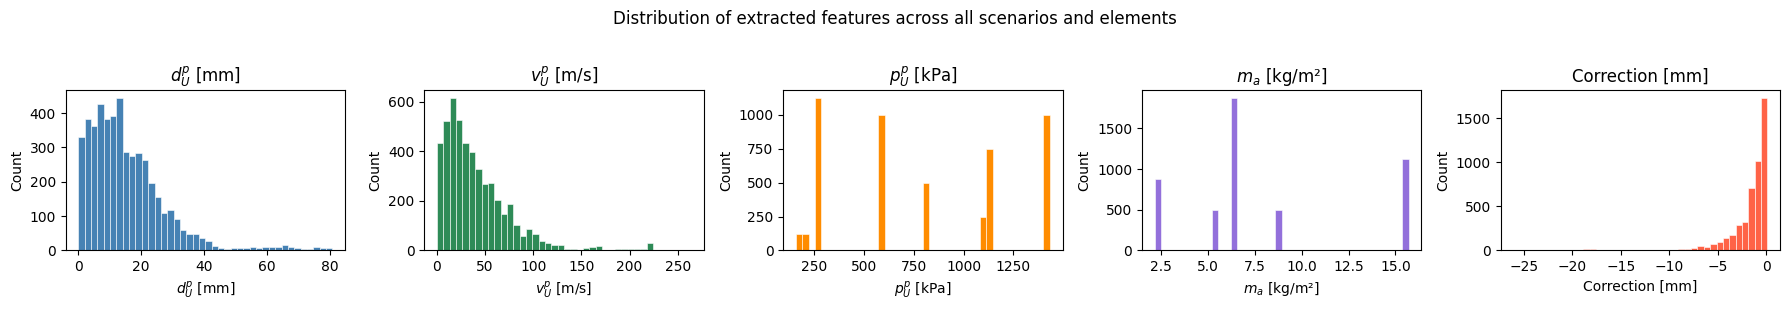


Summary statistics:
            d_U       v_U       p_U       m_a  correction
count  4875.000  4875.000  4875.000  4875.000    4875.000
mean     15.515    41.036   794.361     7.890      -2.047
std      12.564    36.294   446.846     4.653       3.482
min       0.052     0.105   156.341     2.160     -26.066
25%       6.826    16.437   256.021     5.400      -2.261
50%      12.943    31.817   797.011     6.280      -0.969
75%      20.765    55.963  1125.310     8.910      -0.380
max      80.692   263.832  1433.600    15.700       0.113


In [ ]:
# ── Visualise the extracted features ─────────────────────────────────────────
# A quick look at the distribution of inputs and the target across the full dataset.

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
cols    = ['d_U', 'v_U', 'p_U', 'm_a', 'correction']
labels  = ['$d^p_U$ [mm]', '$v^p_U$ [m/s]', '$p^p_U$ [kPa]',
           '$m_a$ [kg/m²]', 'Correction [mm]']
colors  = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple', 'tomato']

for ax, col, label, color in zip(axes, cols, labels, colors):
    ax.hist(df[col], bins=40, color=color, edgecolor='white', linewidth=0.4)
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Count')
    ax.set_title(label)

plt.suptitle('Distribution of extracted features across all scenarios and elements', y=1.02)
plt.tight_layout()
plt.show()

print()
print('Summary statistics:')
print(df[cols].describe().round(3))

In [ ]:
# ── Sanity check: correction factor should be <= 0 ────────────────────────────
# FSI always reduces displacement relative to the uncoupled prediction.

n_positive = (df['correction'] > 0).sum()
n_total    = len(df)

print(f'Rows with positive correction: {n_positive} / {n_total}')
if n_positive == 0:
    print('✅ All correction factors are <= 0. Consistent with FSI physics.')
else:
    print('⚠️  Some positive values found — check CENTRE_ELEM index or data integrity.')

print()
print('Correction factor range:')
print(f'  min : {df["correction"].min():.3f} mm')
print(f'  max : {df["correction"].max():.3f} mm')
print(f'  mean: {df["correction"].mean():.3f} mm')

Rows with positive correction: 23 / 4875
⚠️  Some positive values found — check CENTRE_ELEM index or data integrity.

Correction factor range:
  min : -26.066 mm
  max : 0.113 mm
  mean: -2.047 mm


### ✅ End of Block 3

You now have a clean feature table `df` with one row per element per scenario. Each row contains:
- Three inputs from the uncoupled simulation: $d^p_U$, $v^p_U$, $p^p_U$
- One plate property: $m_a$
- One target: the FSI correction factor $d^p_C - d^p_U$

Notice from the histograms that:
- $m_a$ takes only a **small number of discrete values** — one per material/thickness combination
- The correction factor is concentrated near zero (most elements are away from the plate centre where FSI effects are largest)

In the next block, we will split this table into **training and test sets** — following the exact scenario-based logic from the paper — and prepare the PyTorch data structures.

---
## Block 4 — Train/Test Split and PyTorch Data Structures

### Why not a random split?

In standard supervised learning, data is split randomly into train and test sets. Here, that would be **wrong**.

Each scenario corresponds to a specific combination of material, thickness, and blast intensity. If elements from the same scenario appear in both train and test, the network could trivially interpolate rather than generalise. We want to test whether the network performs well on **entirely unseen scenarios** — unseen materials, unseen thicknesses, unseen load cases.

This is called a **scenario-based split**, and it is the physically meaningful way to evaluate generalisation in this problem.

### DNN1 vs DNN5 splits

We will prepare two separate splits, following the paper exactly:

| Network | Training data | Test data | $m_a$ in input? |
|---|---|---|---|
| **DNN1** | Docol600DL 0.8mm — LC05, LC15, LC35, LC60 | All other scenarios | ❌ No |
| **DNN5** | All aluminium plates (multiple thicknesses) — selected load cases | All steel plates + unseen load cases | ✅ Yes |

The key difference: DNN1 trains on a **single** $m_a$ value and never sees $m_a$ as an input. DNN5 trains on **multiple** $m_a$ values and uses $m_a$ as a feature. We will later see what this means for generalisation.

In [ ]:
# ── Define training scenarios for DNN1 and DNN5 ───────────────────────────────
# These follow Table 5 of the paper exactly.

# First, print all unique load case names in the dataset so we use the exact keys
all_lcs = df['load_case'].unique()
print('Load case names found in dataset:')
print(sorted(all_lcs))
print()

# DNN1: single steel material, single thickness, 4 load cases
# Paper: LC05, LC15, LC35, LC60 -> dataset: D7705, D7715, D7735, D7760
DNN1_TRAIN = [
    ('Docol600DL', '0.8mm', 'D7705'),
    ('Docol600DL', '0.8mm', 'D7715'),
    ('Docol600DL', '0.8mm', 'D7735'),
    ('Docol600DL', '0.8mm', 'D7760'),
]

# DNN5: aluminium plates only, multiple thicknesses, selected load cases
# Paper: LCA05, LCA7.5, LCA10 -> dataset: A5, A7, A10
# Paper: LC05, LC15, LC35, LC60 -> dataset: D7705, D7715, D7735, D7760
DNN5_TRAIN = [
    ('1050-H14', '0.8mm', 'A5'),
    ('1050-H14', '0.8mm', 'A7'),
    ('1050-H14', '0.8mm', 'A10'),
    ('6082-T6',  '0.8mm', 'D7705'),
    ('6082-T6',  '0.8mm', 'D7715'),
    ('6082-T6',  '0.8mm', 'D7735'),
    ('6082-T6',  '0.8mm', 'D7760'),
    ('6082-T6',  '2.0mm', 'D7705'),
    ('6082-T6',  '2.0mm', 'D7715'),
    ('6082-T6',  '2.0mm', 'D7735'),
    ('6082-T6',  '2.0mm', 'D7760'),
    ('6082-T6',  '3.3mm', 'D7705'),
    ('6082-T6',  '3.3mm', 'D7715'),
    ('6082-T6',  '3.3mm', 'D7735'),
    ('6082-T6',  '3.3mm', 'D7760'),
    ('6082-T6',  '5.8mm', 'D7705'),
    ('6082-T6',  '5.8mm', 'D7715'),
    ('6082-T6',  '5.8mm', 'D7735'),
    ('6082-T6',  '5.8mm', 'D7760'),
]

print(f'DNN1 training scenarios: {len(DNN1_TRAIN)}')
print(f'DNN5 training scenarios: {len(DNN5_TRAIN)}')

Load case names found in dataset:
['A10', 'A5', 'A7', 'D7705', 'D7715', 'D7725', 'D7735', 'D7760']

DNN1 training scenarios: 4
DNN5 training scenarios: 19


In [ ]:
# ── Helper: split df into train and test based on scenario lists ──────────────

def scenario_split(df, train_scenarios):
    """
    Split the feature DataFrame into train and test subsets.

    Parameters
    ----------
    df : pd.DataFrame
        Full feature table with columns material, thickness, load_case, ...
    train_scenarios : list of (material, thickness, load_case) tuples

    Returns
    -------
    df_train, df_test : pd.DataFrames
    """
    train_set = set(train_scenarios)
    mask = df.apply(
        lambda row: (row['material'], row['thickness'], row['load_case']) in train_set,
        axis=1
    )
    return df[mask].reset_index(drop=True), df[~mask].reset_index(drop=True)


df_dnn1_train, df_dnn1_test = scenario_split(df, DNN1_TRAIN)
df_dnn5_train, df_dnn5_test = scenario_split(df, DNN5_TRAIN)

print('DNN1 — train rows:', len(df_dnn1_train), ' | test rows:', len(df_dnn1_test))
print('DNN5 — train rows:', len(df_dnn5_train), ' | test rows:', len(df_dnn5_test))
print()
print('DNN1 test scenarios (should include multiple materials and thicknesses):')
print(df_dnn1_test[['material','thickness','load_case']].drop_duplicates().to_string(index=False))

DNN1 — train rows: 500  | test rows: 4375
DNN5 — train rows: 2375  | test rows: 2500

DNN1 test scenarios (should include multiple materials and thicknesses):
   material thickness load_case
 Docol600DL     0.8mm     D7725
 Docol600DL     2.0mm     D7705
 Docol600DL     2.0mm     D7715
 Docol600DL     2.0mm     D7725
 Docol600DL     2.0mm     D7735
 Docol600DL     2.0mm     D7760
Docol1000DP     0.8mm     D7705
Docol1000DP     0.8mm     D7715
Docol1000DP     0.8mm     D7725
Docol1000DP     0.8mm     D7735
Docol1000DP     0.8mm     D7760
 Docol1400M     0.8mm     D7705
 Docol1400M     0.8mm     D7715
 Docol1400M     0.8mm     D7725
 Docol1400M     0.8mm     D7735
 Docol1400M     0.8mm     D7760
   1050-H14     0.8mm        A5
   1050-H14     0.8mm        A7
   1050-H14     0.8mm       A10
    6082-T6     2.0mm     D7705
    6082-T6     2.0mm     D7715
    6082-T6     2.0mm     D7735
    6082-T6     2.0mm     D7760
    6082-T6     0.8mm     D7705
    6082-T6     0.8mm     D7715
    6082-

In [ ]:
# ── Min-max normalisation ─────────────────────────────────────────────────────
# Following equation (5) of the paper: normalise using TRAINING data statistics only.
# The same statistics are then applied to the test set — never fit on test data.
#
# DNN1 uses 3 inputs: d_U, v_U, p_U
# DNN5 uses 4 inputs: d_U, v_U, p_U, m_a

def minmax_normalise(train_df, test_df, feature_cols, target_col):
    """
    Fit min-max scaler on training data, apply to both train and test.

    Returns normalised numpy arrays: X_train, y_train, X_test, y_test,
    and the scaler parameters (min, max) for the target (needed to denormalise later).
    """
    # Fit on training data
    X_min = train_df[feature_cols].min().values
    X_max = train_df[feature_cols].max().values
    y_min = train_df[target_col].min()
    y_max = train_df[target_col].max()

    # Normalise: v_norm = (v - min) / (max - min)
    X_train = (train_df[feature_cols].values - X_min) / (X_max - X_min)
    y_train = (train_df[target_col].values  - y_min) / (y_max - y_min)

    X_test  = (test_df[feature_cols].values  - X_min) / (X_max - X_min)
    y_test  = (test_df[target_col].values   - y_min) / (y_max - y_min)

    scaler = {'X_min': X_min, 'X_max': X_max, 'y_min': y_min, 'y_max': y_max}
    return X_train, y_train, X_test, y_test, scaler


FEATURES_DNN1 = ['d_U', 'v_U', 'p_U']
FEATURES_DNN5 = ['d_U', 'v_U', 'p_U', 'm_a']
TARGET        = 'correction'

X1_train, y1_train, X1_test, y1_test, scaler1 = minmax_normalise(
    df_dnn1_train, df_dnn1_test, FEATURES_DNN1, TARGET)

X5_train, y5_train, X5_test, y5_test, scaler5 = minmax_normalise(
    df_dnn5_train, df_dnn5_test, FEATURES_DNN5, TARGET)

print('DNN1 — X_train:', X1_train.shape, ' y_train:', y1_train.shape)
print('DNN1 — X_test: ', X1_test.shape,  ' y_test: ', y1_test.shape)
print()
print('DNN5 — X_train:', X5_train.shape, ' y_train:', y5_train.shape)
print('DNN5 — X_test: ', X5_test.shape,  ' y_test: ', y5_test.shape)

DNN1 — X_train: (500, 3)  y_train: (500,)
DNN1 — X_test:  (4375, 3)  y_test:  (4375,)

DNN5 — X_train: (2375, 4)  y_train: (2375,)
DNN5 — X_test:  (2500, 4)  y_test:  (2500,)


In [ ]:
# ── Wrap arrays in PyTorch Datasets and DataLoaders ───────────────────────────
# PyTorch expects data as float32 tensors.
# We use an 80/20 split of the training data for train/validation.
# Tensors are moved to the device (GPU if available) for faster training.

from torch.utils.data import TensorDataset, DataLoader, random_split

def make_loaders(X_train, y_train, X_test, y_test, batch_size=32, val_frac=0.2):
    """
    Build train, validation and test DataLoaders from numpy arrays.
    All tensors are moved to `device` (GPU if available).
    """
    # Convert to float32 tensors and move to device
    X_tr = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tr = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
    X_te = torch.tensor(X_test,  dtype=torch.float32).to(device)
    y_te = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1).to(device)

    full_train_ds = TensorDataset(X_tr, y_tr)
    test_ds       = TensorDataset(X_te, y_te)

    # Train / validation split
    n_val   = int(len(full_train_ds) * val_frac)
    n_train = len(full_train_ds) - n_val
    train_ds, val_ds = random_split(
        full_train_ds, [n_train, n_val],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


loaders1 = make_loaders(X1_train, y1_train, X1_test, y1_test)
loaders5 = make_loaders(X5_train, y5_train, X5_test, y5_test)

train1_loader, val1_loader, test1_loader = loaders1
train5_loader, val5_loader, test5_loader = loaders5

print('DNN1 DataLoaders ready.')
print(f'  Train batches: {len(train1_loader)} | Val batches: {len(val1_loader)} | Test batches: {len(test1_loader)}')
print()
print('DNN5 DataLoaders ready.')
print(f'  Train batches: {len(train5_loader)} | Val batches: {len(val5_loader)} | Test batches: {len(test5_loader)}')

DNN1 DataLoaders ready.
  Train batches: 13 | Val batches: 4 | Test batches: 137

DNN5 DataLoaders ready.
  Train batches: 60 | Val batches: 15 | Test batches: 79


### ✅ End of Block 4

You now have everything needed to train the networks:
- A **scenario-based** train/test split for both DNN1 and DNN5
- Min-max normalised features, fitted on training data only
- PyTorch `DataLoader` objects for train, validation, and test sets

**Pause and reflect:** look at the test scenarios printed for DNN1. They include materials and thicknesses the network has never seen. Its 3-input design — without $m_a$ — means it has no way to distinguish a light aluminium plate from a heavy steel one. DNN5, trained on aluminium across multiple thicknesses with $m_a$ as an explicit input, has exactly that information.

In the next block, we will **define and train both networks**.

---
## Block 5 — Model Definition and Training

### Architecture recap

Both networks are feed-forward DNNs. From Table 7 of the paper:

| Network | Inputs | Hidden layers | Nodes per layer | Activation |
|---|---|---|---|---|
| DNN1 | 3 ($d^p_U$, $v^p_U$, $p^p_U$) | 2 | 5, 3 | Sigmoid |
| DNN5 | 4 ($d^p_U$, $v^p_U$, $p^p_U$, $m_a$) | 2 | 500, 500 | Tanh |

Both have a single output neuron with **no activation** — this is a regression problem.

### Training setup

Following the paper:
- **Loss**: Mean Squared Error (MSE)
- **Optimiser**: AMSGrad (Adam variant with guaranteed convergence)
- **Early stopping**: halt if validation loss does not improve for 100 consecutive epochs
- **Max epochs**: 10,000

### Your task

The training loop is provided. **You need to fill in the model architectures** in the cell marked `# YOUR CODE HERE`.

In [ ]:
import torch.nn as nn

# ── YOUR CODE HERE — define DNN1 ─────────────────────────────────────────────
# 3 inputs | hidden layers: 5 nodes then 3 nodes | Sigmoid activations | 1 output (no activation)

dnn1 = nn.Sequential(
    # hidden layer 1 ...
    # hidden layer 2 ...
    # output layer  ...
)

# ── YOUR CODE HERE — define DNN5 ─────────────────────────────────────────────
# 4 inputs | hidden layers: 500 nodes, 500 nodes | Tanh activations | 1 output (no activation)

dnn5 = nn.Sequential(
    # hidden layer 1 ...
    # hidden layer 2 ...
    # output layer  ...
)

print('DNN1 architecture:')
print(dnn1)
print()
print('DNN5 architecture:')
print(dnn5)
print()
total1 = sum(p.numel() for p in dnn1.parameters())
total5 = sum(p.numel() for p in dnn5.parameters())
print(f'DNN1 trainable parameters: {total1:,}')
print(f'DNN5 trainable parameters: {total5:,}')

DNN1 architecture:
Sequential()

DNN5 architecture:
Sequential()

DNN1 trainable parameters: 0
DNN5 trainable parameters: 0


In [ ]:
# ── SOLUTION — run this cell if you are stuck ────────────────────────────────

dnn1 = nn.Sequential(
    nn.Linear(3, 5),   nn.Sigmoid(),
    nn.Linear(5, 3),   nn.Sigmoid(),
    nn.Linear(3, 1),
)

dnn5 = nn.Sequential(
    nn.Linear(4, 500),   nn.Tanh(),
    nn.Linear(500, 500), nn.Tanh(),
    nn.Linear(500, 1),
)

print('DNN1 architecture:')
print(dnn1)
print()
print('DNN5 architecture:')
print(dnn5)
print()
total1 = sum(p.numel() for p in dnn1.parameters())
total5 = sum(p.numel() for p in dnn5.parameters())
print(f'DNN1 trainable parameters: {total1:,}')
print(f'DNN5 trainable parameters: {total5:,}')

DNN1 architecture:
Sequential(
  (0): Linear(in_features=3, out_features=5, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=5, out_features=3, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=3, out_features=1, bias=True)
)

DNN5 architecture:
Sequential(
  (0): Linear(in_features=4, out_features=500, bias=True)
  (1): Tanh()
  (2): Linear(in_features=500, out_features=500, bias=True)
  (3): Tanh()
  (4): Linear(in_features=500, out_features=1, bias=True)
)

DNN1 trainable parameters: 42
DNN5 trainable parameters: 253,501


In [ ]:
# ── Training loop (pre-written) ───────────────────────────────────────────────

def train_model(model, train_loader, val_loader,
                lr=2e-5, max_epochs=1500, patience=100):
    """
    Train a regression model with early stopping.
    The model is automatically moved to `device` (GPU if available).

    Parameters
    ----------
    model        : nn.Module
    train_loader : DataLoader
    val_loader   : DataLoader
    lr           : float  — learning rate (paper: 2e-5)
    max_epochs   : int    — hard cap (paper: 10,000)
    patience     : int    — early stopping patience (paper: 100 epochs)

    Returns
    -------
    model        : weights restored to best validation epoch, back on CPU
    train_losses : list of per-epoch training MSE
    val_losses   : list of per-epoch validation MSE
    """
    model = model.to(device)

    criterion = nn.MSELoss()
    optimiser = torch.optim.Adam(
        model.parameters(), lr=lr, amsgrad=True,
        betas=(0.9, 0.999), eps=1e-7
    )

    best_val_loss      = float('inf')
    best_weights       = None
    epochs_no_improve  = 0
    train_losses, val_losses = [], []

    for epoch in range(1, max_epochs + 1):

        # Training pass
        model.train()
        batch_losses = []
        for X_batch, y_batch in train_loader:
            optimiser.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimiser.step()
            batch_losses.append(loss.item())
        train_losses.append(float(np.mean(batch_losses)))

        # Validation pass
        model.eval()
        with torch.no_grad():
            vbl = [criterion(model(X), y).item() for X, y in val_loader]
        val_loss = float(np.mean(vbl))
        val_losses.append(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_weights   = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f'  Early stopping at epoch {epoch}  '
                  f'(best val MSE: {best_val_loss:.5f})')
            break

        if epoch % 20 == 0:
            print(f'  Epoch {epoch:5d} — train MSE: {train_losses[-1]:.5f}  '
                  f'val MSE: {val_loss:.5f}')

    # Restore best weights and move model back to CPU for evaluation
    model.load_state_dict(best_weights)
    model = model.to('cpu')
    return model, train_losses, val_losses

print('train_model() defined.')

train_model() defined.


In [ ]:
# ── Train DNN1 ────────────────────────────────────────────────────────────────
print('Training DNN1 ...')
dnn1, train_losses1, val_losses1 = train_model(dnn1, train1_loader, val1_loader)
print('DNN1 training complete.')

Training DNN1 ...
  Epoch    20 — train MSE: 0.73545  val MSE: 0.63026
  Epoch    40 — train MSE: 0.71185  val MSE: 0.60721
  Epoch    60 — train MSE: 0.68588  val MSE: 0.58478
  Epoch    80 — train MSE: 0.66133  val MSE: 0.56295
  Epoch   100 — train MSE: 0.63981  val MSE: 0.54173
  Epoch   120 — train MSE: 0.60616  val MSE: 0.52107
  Epoch   140 — train MSE: 0.58484  val MSE: 0.50095
  Epoch   160 — train MSE: 0.56428  val MSE: 0.48145
  Epoch   180 — train MSE: 0.54609  val MSE: 0.46247
  Epoch   200 — train MSE: 0.52300  val MSE: 0.44410
  Epoch   220 — train MSE: 0.50154  val MSE: 0.42639
  Epoch   240 — train MSE: 0.47845  val MSE: 0.40934
  Epoch   260 — train MSE: 0.46506  val MSE: 0.39297
  Epoch   280 — train MSE: 0.44641  val MSE: 0.37728
  Epoch   300 — train MSE: 0.42633  val MSE: 0.36227
  Epoch   320 — train MSE: 0.40436  val MSE: 0.34793
  Epoch   340 — train MSE: 0.39251  val MSE: 0.33423
  Epoch   360 — train MSE: 0.38023  val MSE: 0.32118
  Epoch   380 — train MSE: 0

In [ ]:
# ── Train DNN5 ────────────────────────────────────────────────────────────────
print('Training DNN5 ...')
dnn5, train_losses5, val_losses5 = train_model(dnn5, train5_loader, val5_loader)
print('DNN5 training complete.')

Training DNN5 ...
  Epoch    20 — train MSE: 0.00281  val MSE: 0.00276
  Epoch    40 — train MSE: 0.00228  val MSE: 0.00221
  Epoch    60 — train MSE: 0.00188  val MSE: 0.00182
  Epoch    80 — train MSE: 0.00154  val MSE: 0.00158
  Epoch   100 — train MSE: 0.00127  val MSE: 0.00129
  Epoch   120 — train MSE: 0.00104  val MSE: 0.00108
  Epoch   140 — train MSE: 0.00086  val MSE: 0.00090
  Epoch   160 — train MSE: 0.00071  val MSE: 0.00076
  Epoch   180 — train MSE: 0.00060  val MSE: 0.00063
  Epoch   200 — train MSE: 0.00052  val MSE: 0.00057
  Epoch   220 — train MSE: 0.00047  val MSE: 0.00052
  Epoch   240 — train MSE: 0.00044  val MSE: 0.00046
  Epoch   260 — train MSE: 0.00042  val MSE: 0.00044
  Epoch   280 — train MSE: 0.00041  val MSE: 0.00043
  Epoch   300 — train MSE: 0.00040  val MSE: 0.00042
  Epoch   320 — train MSE: 0.00039  val MSE: 0.00041
  Epoch   340 — train MSE: 0.00038  val MSE: 0.00040
  Epoch   360 — train MSE: 0.00038  val MSE: 0.00039
  Epoch   380 — train MSE: 0

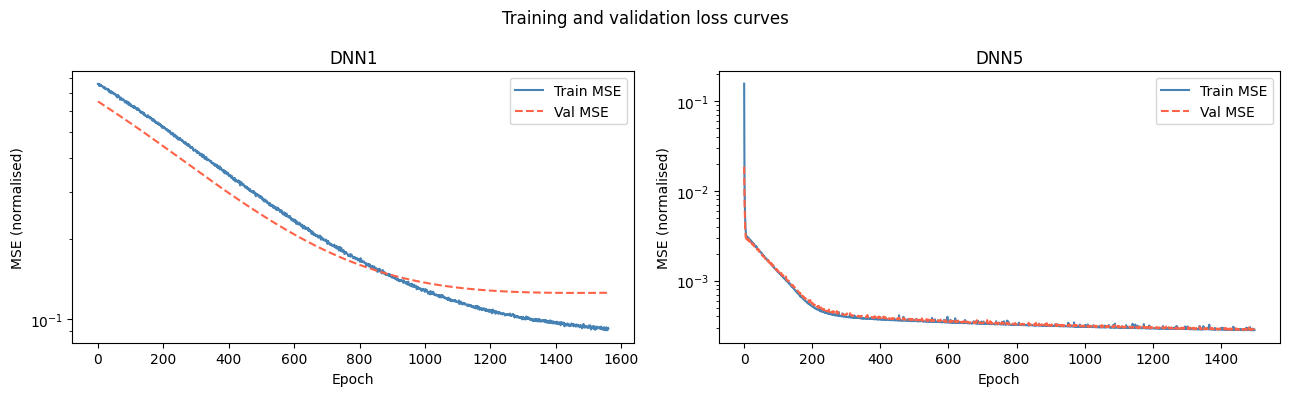

DNN1 — final train MSE: 0.09221 | final val MSE: 0.12537
DNN5 — final train MSE: 0.00028 | final val MSE: 0.00028


In [ ]:
# ── Plot training and validation loss curves ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, tl, vl, name in zip(
        axes,
        [train_losses1, train_losses5],
        [val_losses1,   val_losses5],
        ['DNN1', 'DNN5']):

    ax.plot(tl, label='Train MSE', color='steelblue')
    ax.plot(vl, label='Val MSE',   color='tomato', linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE (normalised)')
    ax.set_title(name)
    ax.legend()
    ax.set_yscale('log')

plt.suptitle('Training and validation loss curves', fontsize=12)
plt.tight_layout()
plt.show()

print(f'DNN1 — final train MSE: {train_losses1[-1]:.5f} | final val MSE: {val_losses1[-1]:.5f}')
print(f'DNN5 — final train MSE: {train_losses5[-1]:.5f} | final val MSE: {val_losses5[-1]:.5f}')

### ✅ End of Block 5

Both networks are now trained. A few things to observe from the loss curves before moving on:
- Do train and validation losses track each other, or does one diverge? Divergence indicates overfitting.
- DNN5 has ~250,000 parameters vs ~50 for DNN1. Does that translate to a lower training loss?
- The early stopping epoch tells you how quickly each network converged.

In the next block, we will run both networks on the **test set** — scenarios neither network has seen — and understand why one generalises and the other does not.

---
## Block 6 — Evaluation and Comparison

Both networks are trained. Now we evaluate them on the **test set** — scenarios neither network has ever seen during training.

We will do this in three steps:

1. **Predictions vs targets scatter plot** — if the network generalises perfectly, all points lie on the diagonal $y = x$
2. **Cross-sectional displacement profiles** — recreating the key figures from the paper: predicted vs uncoupled vs coupled displacement along the plate cross-section for selected test scenarios
3. **Interpretation** — understanding *why* DNN1 fails on certain scenarios and DNN5 does not

All predictions are in **normalised space** from the network output, then denormalised back to mm for physical interpretation.

In [ ]:
# ── Helper: run a trained model on a DataLoader, return denormalised predictions ──

def predict(model, loader, scaler):
    """
    Run model inference on all batches in loader.
    Returns predictions and targets, both denormalised to physical units [mm].
    """
    model = model.to(device)
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds.append(model(X_batch).cpu().numpy())
            targets.append(y_batch.cpu().numpy())

    preds   = np.concatenate(preds).flatten()
    targets = np.concatenate(targets).flatten()

    # Denormalise: v = v_norm * (max - min) + min
    y_min, y_max = scaler['y_min'], scaler['y_max']
    preds   = preds   * (y_max - y_min) + y_min
    targets = targets * (y_max - y_min) + y_min

    return preds, targets


preds1_test,  targets1_test  = predict(dnn1, test1_loader,  scaler1)
preds5_test,  targets5_test  = predict(dnn5, test5_loader,  scaler5)

print('Predictions computed.')
print(f'DNN1 test — MSE: {np.mean((preds1_test - targets1_test)**2):.4f} mm²')
print(f'DNN5 test — MSE: {np.mean((preds5_test - targets5_test)**2):.4f} mm²')

Predictions computed.
DNN1 test — MSE: 14.0240 mm²
DNN5 test — MSE: 0.0803 mm²


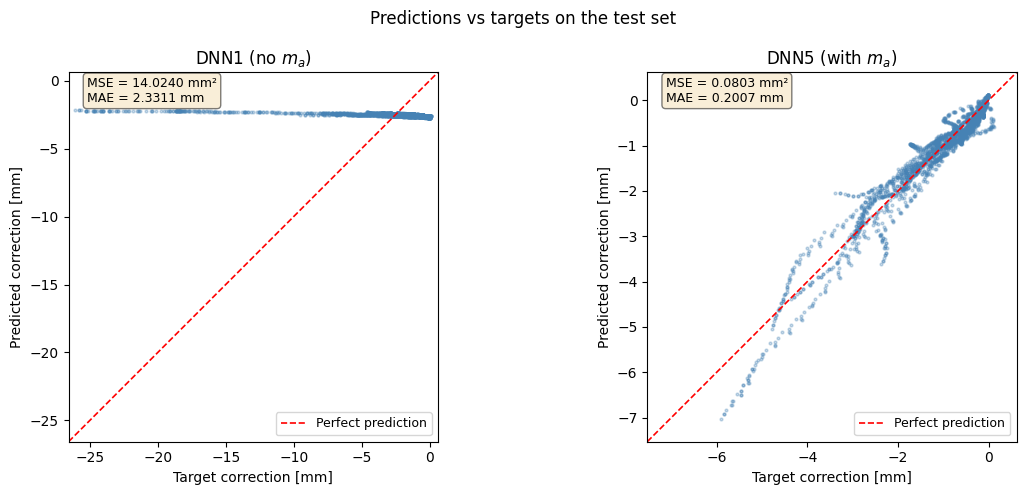

In [ ]:
# ── Predictions vs targets scatter plot ──────────────────────────────────────
# Points on the diagonal = perfect prediction.
# Spread around the diagonal = prediction error.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, targets, name in zip(
        axes,
        [preds1_test,  preds5_test],
        [targets1_test, targets5_test],
        ['DNN1 (no $m_a$)', 'DNN5 (with $m_a$)']):

    lim = [min(targets.min(), preds.min()) - 0.5,
           max(targets.max(), preds.max()) + 0.5]

    ax.scatter(targets, preds, s=4, alpha=0.3, color='steelblue')
    ax.plot(lim, lim, 'r--', linewidth=1.2, label='Perfect prediction')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Target correction [mm]')
    ax.set_ylabel('Predicted correction [mm]')
    ax.set_title(name)
    ax.legend(fontsize=9)
    ax.set_aspect('equal')

    mse  = np.mean((preds - targets)**2)
    mae  = np.mean(np.abs(preds - targets))
    ax.text(0.05, 0.92, f'MSE = {mse:.4f} mm²\nMAE = {mae:.4f} mm',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Predictions vs targets on the test set', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ── Setup for cross-sectional displacement profiles ───────────────────────────
# Element ordering in the quarter-model mesh:
#   - Elements are stored column by column, starting from the plate centre
#   - Each column has 25 elements, ordered from centre outward (bottom to top)
#   - After 25 elements (one column), the next column begins
#   - Total: 125 elements = 5 columns x 25 elements
#
# Layout (element indices, 0-based):
#    0  25  50  75  100   <- centre row (closest to plate centre)
#    1  26  51  76  101
#    .   .   .   .    .
#   24  49  74  99  124   <- edge row (plate boundary)
#
# For a cross-sectional profile, we take the FIRST column (elements 0-24),
# which represents the displacement from plate centre to edge along one axis.

N_COLS     = 5
N_ROWS     = 25   # elements per column
COL_IDX    = 0    # which column to plot (0 = centre column)

def get_profile_predictions(model, df_test, feature_cols, scaler, scenario):
    """
    For a single scenario, extract the displacement profile along the
    centre column (elements 0..24), from plate centre to edge.

    Returns
      elem_pos   : position index 0..N_ROWS-1 (centre -> edge)
      d_U        : uncoupled displacement [mm]
      d_corrected: d_U + predicted correction [mm]
      d_C        : d_U + true correction [mm]  (coupled ground truth)
    """
    mat, th, lc = scenario
    mask = ((df_test['material']  == mat) &
            (df_test['thickness'] == th)  &
            (df_test['load_case'] == lc))
    df_scen = df_test[mask].sort_values('element').reset_index(drop=True)

    if len(df_scen) == 0:
        raise ValueError(f'Scenario {scenario} not found in test set.')

    # Extract only the centre column: element indices COL_IDX*N_ROWS .. (COL_IDX+1)*N_ROWS - 1
    col_start = COL_IDX * N_ROWS
    col_end   = col_start + N_ROWS
    df_col = df_scen.iloc[col_start:col_end].reset_index(drop=True)

    # Position along the cross-section: 0 = plate centre, N_ROWS-1 = plate edge
    elem_pos = df_col.index.values

    # Normalise inputs and move to device
    X_min, X_max = scaler['X_min'], scaler['X_max']
    X = torch.tensor(
        (df_col[feature_cols].values - X_min) / (X_max - X_min),
        dtype=torch.float32
    ).to(device)

    # Predict and denormalise correction
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        pred_norm = model(X).cpu().numpy().flatten()
    y_min, y_max = scaler['y_min'], scaler['y_max']
    pred_correction = pred_norm * (y_max - y_min) + y_min

    d_U       = df_col['d_U'].values
    true_corr = df_col['correction'].values

    return elem_pos, d_U, d_U + pred_correction, d_U + true_corr

print('get_profile_predictions() defined.')
print(f'Plotting column {COL_IDX} — elements {COL_IDX*N_ROWS} to {COL_IDX*N_ROWS + N_ROWS - 1} (centre -> edge)')

get_profile_predictions() defined.
Plotting column 0 — elements 0 to 24 (centre -> edge)


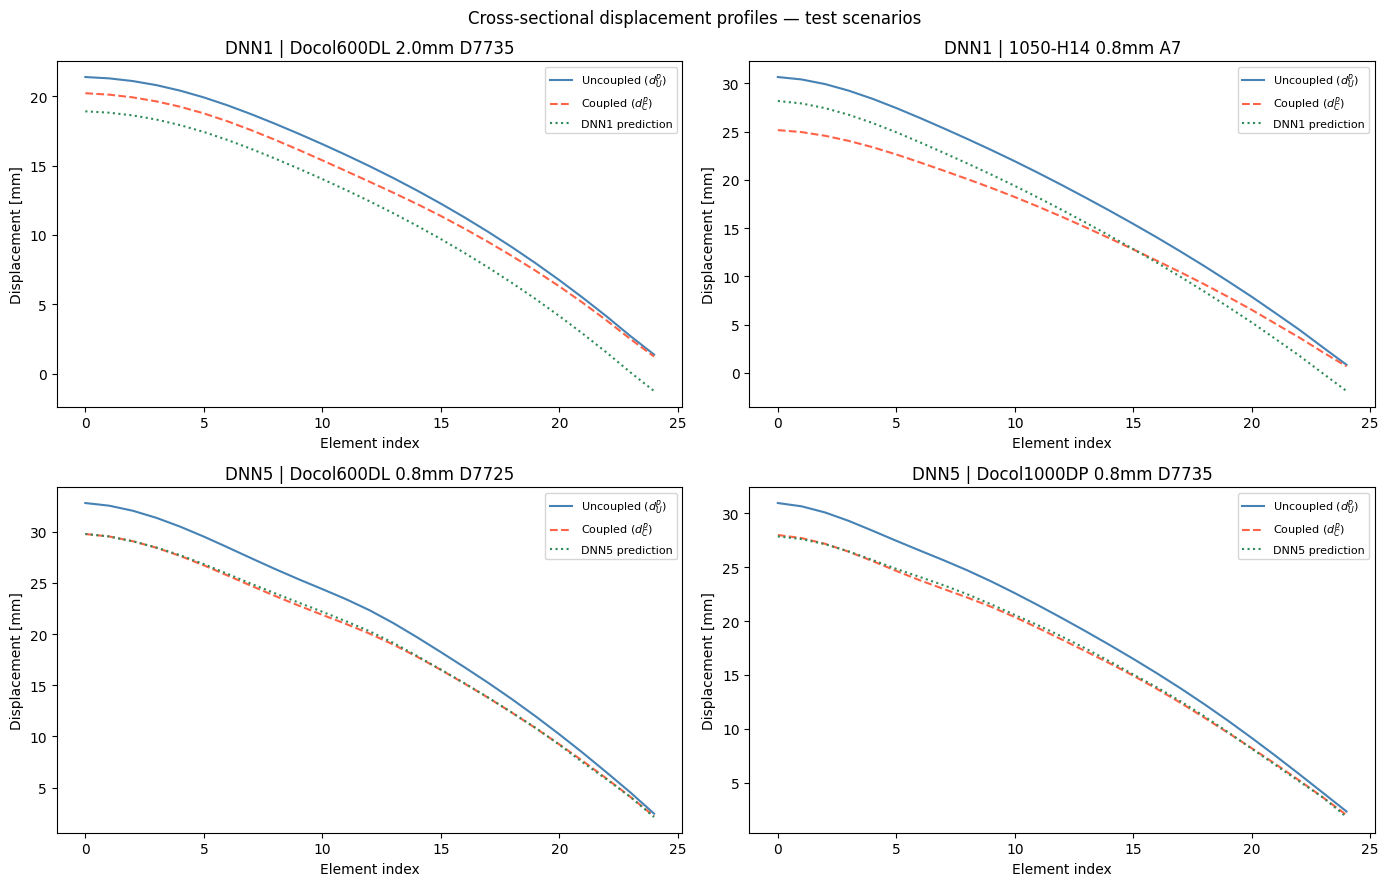

In [ ]:
# ── Cross-sectional displacement profiles for selected test scenarios ─────────
# We pick one scenario where DNN1 is expected to struggle (different m_a)
# and one where DNN5 should generalise well (unseen steel + unseen load case).
#
# Adjust the scenario tuples below if these are not in your test set.

SCENARIOS_DNN1 = [
    ('Docol600DL',  '2.0mm', 'D7735'),   # heavier steel — different m_a from training
    ('1050-H14',    '0.8mm', 'A7'),       # aluminium — completely different material
]

SCENARIOS_DNN5 = [
    ('Docol600DL',  '0.8mm', 'D7725'),   # steel, unseen load case (LC25)
    ('Docol1000DP', '0.8mm', 'D7735'),   # different steel grade, unseen material
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Cross-sectional displacement profiles — test scenarios', fontsize=12)

plot_configs = [
    (axes[0, 0], dnn1, df_dnn1_test, FEATURES_DNN1, scaler1, SCENARIOS_DNN1[0], 'DNN1'),
    (axes[0, 1], dnn1, df_dnn1_test, FEATURES_DNN1, scaler1, SCENARIOS_DNN1[1], 'DNN1'),
    (axes[1, 0], dnn5, df_dnn5_test, FEATURES_DNN5, scaler5, SCENARIOS_DNN5[0], 'DNN5'),
    (axes[1, 1], dnn5, df_dnn5_test, FEATURES_DNN5, scaler5, SCENARIOS_DNN5[1], 'DNN5'),
]

for ax, model, df_test, feats, scaler, scenario, dnn_name in plot_configs:
    try:
        elem_idx, d_U, d_corr, d_C = get_profile_predictions(
            model, df_test, feats, scaler, scenario)

        ax.plot(elem_idx, d_U,    color='steelblue', label='Uncoupled ($d^p_U$)')
        ax.plot(elem_idx, d_C,    color='tomato',    label='Coupled ($d^p_C$)',    linestyle='--')
        ax.plot(elem_idx, d_corr, color='seagreen',  label=f'{dnn_name} prediction', linestyle=':')
        ax.set_xlabel('Element index')
        ax.set_ylabel('Displacement [mm]')
        mat, th, lc = scenario
        ax.set_title(f'{dnn_name} | {mat} {th} {lc}')
        ax.legend(fontsize=8)
    except ValueError as e:
        ax.text(0.5, 0.5, str(e), transform=ax.transAxes,
                ha='center', va='center', color='red', fontsize=9)
        ax.set_title(f'Scenario not found')

plt.tight_layout()
plt.show()

### Interpretation

Look at the four panels and answer the following questions:

**DNN1 panels (top row)**
- For the heavier steel plate (2.0mm, $m_a = 15.7$ kg/m²): does DNN1 over- or under-estimate the FSI correction? Why? *(Hint: DNN1 only trained on $m_a = 6.3$ kg/m².)*
- For the aluminium plate: the correction is in the wrong direction or badly scaled. Why can DNN1 not generalise here?

**DNN5 panels (bottom row)**
- For the unseen steel load case: DNN5 was trained only on aluminium, yet it predicts steel FSI corrections accurately. What is the physical quantity that allows it to generalise across materials?
- For the unseen steel grade: same question — DNN5 has never seen Docol1000DP, yet it performs well. What does this tell us about which material property drives FSI effects?

**The key insight:** DNN1 fails whenever $m_a$ is different from its training value because it has no way to encode that information. DNN5 generalises because $m_a$ is an explicit input — the network learned that *mass per unit area*, not material grade or yield strength, is the governing parameter of FSI effects. This is the central finding of the paper.

### ✅ End of Block 6 — Session complete

You have built, trained and evaluated two deep neural networks on a real engineering dataset. The full pipeline you followed:

1. Loaded and explored raw time-series simulation data
2. Extracted physically meaningful scalar features
3. Assembled a scenario-based train/test split that tests true generalisation
4. Defined and trained two networks with different input sets
5. Evaluated them on unseen scenarios and interpreted the results

The comparison between DNN1 and DNN5 illustrates a general principle in data-driven engineering:

> **What you give the network matters as much as how you train it.** A network that lacks a governing physical variable will never generalise beyond its training distribution, regardless of how well it is optimised.

This is why domain knowledge — knowing that $m_a$ drives FSI — is essential when designing machine learning solutions for engineering problems.